# Linear Regression

A technique for fitting a line to a set of data points.

We assume the response variable can be modeled as such:
$$
\begin{aligned}
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \epsilon
\end{aligned}
$$
A linear combination plus some noise.



# Solutions
There are several ways

## Least Squares
A Linear Regression can be fitted as the optimal fit to an optimization problem

As an example in simple linear regression
$$
\begin{aligned}
cost(\beta_0, \beta_1) &= \sum^n_{i=0} (y_i - \hat{y}_i)^2\\
&= \sum^n_{i=0} (y_i - \beta_0 - \beta_1 x_{i1})^2\\
\frac{\partial}{\partial \beta_0} cost(\beta_0, \beta_1) &= \sum^n_{i=0} 2(y_i - \beta_0 - \beta_1 x_{i1}) (-1)\\
\frac{\partial}{\partial \beta_0} cost(\beta_0, \beta_1) = 0 \implies 0 &= \sum^n_{i=0} 2(y_i - \beta_0 - \beta_1 x_{i1}) (-1)\\
&= \sum^n_{i=0} (y_i - \beta_0 - \beta_1 x_{i1})\\
&= n\bar{y} - n\beta_0 - n\beta_1 \bar{x}_{1}\\
\implies \beta_0 &= \bar{y}-\beta_1 \bar{x}_{1}\\
\frac{\partial}{\partial \beta_1} cost(\beta_0, \beta_1) &= \sum^n_{i=0} 2(y_i - \beta_0 - \beta_1 x_{i1}) (-x_{i1})\\

\end{aligned}
$$


## Matrix Solution

$$
\begin{aligned}
\vec{y} &= 
\begin{pmatrix} 1 & x_{11} & x_{12} & \dots & x_{1p} \\ 1 & x_{21} & x_{22} & \dots & x_{2p} \\ \vdots & \vdots & \vdots & \ddots &\vdots\\ 1 & x_{n1} & x_{n2} & \dots & x_{np}\\ \end{pmatrix} 
\begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{pmatrix} 
= X\vec{\beta}\\
cost(\vec{\beta}) &=  (\vec{y} - X\vec{\beta})^2\\
&= (\vec{y} - X\vec{\beta})^T (\vec{y} - X\vec{\beta})\\
&= \vec{y}^T\vec{y} - \vec{y}^T X\vec{\beta} - (X\vec{\beta})^T\vec{y} + (X\vec{\beta})^T X\vec{\beta}\\
&= \vec{y}^T\vec{y} - 2\vec{\beta}^T X^T\vec{y} + \vec{\beta}^T X^T X\vec{\beta}\\
\frac{\partial }{\partial \vec{\beta}} cost(\vec{\beta}) &= 0 - 2 X^T\vec{y} + 2  X^T X\vec{\beta}\\
\frac{\partial }{\partial \vec{\beta}} cost(\vec{\beta}) = 0 \implies 0 &= - 2 X^T\vec{y} + 2  X^T X\vec{\beta}\\
- 2  X^T X\vec{\beta} &= - 2 X^T\vec{y}\\
\vec{\beta} &= (X^TX)^{-1}X^T\vec{y}\\
\end{aligned}
$$


Note that $\vec{y}^T X\vec{\beta}=(X\vec{\beta})^T\vec{y}$ and that both are scalars because
$$
\begin{aligned}
\vec{y}^T X\vec{\beta} &= \begin{pmatrix} y_1 & y_2 & \dots & y_n \end{pmatrix} \begin{pmatrix} \beta_0 + \beta_1x_{11} + \beta_2x_{12} + \dots +\beta_p x_{1p} \\ \beta_0 +\beta_1 x_{21} +\beta_2 x_{22} + \dots + \beta_p x_{2p} \\ \vdots \\ \beta_0 +\beta_1 x_{n1} + \beta_2 x_{n2} + \dots + \beta_p x_{np}\\ \end{pmatrix} \\
(X\vec{\beta})^T\vec{y} &= \begin{pmatrix} \beta_0 + \beta_1x_{11} + \beta_2x_{12} + \dots +\beta_p x_{1p} & \beta_0 +\beta_1 x_{21} +\beta_2 x_{22} + \dots + \beta_p x_{2p} & \dots & \beta_0 +\beta_1 x_{n1} + \beta_2 x_{n2} + \dots + \beta_p x_{np}\\ \end{pmatrix} \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}
\end{aligned}
$$




# Inference Assumptions

When conducting inference, there are a series of assumptions that must be met
1. Independence
2. Linearity
3. Homoscadascity
4. Error Normality

## Distributions

$$
\begin{aligned}
\vec{\epsilon} &\sim Normal(0,\sigma^2I_n)\\
Y = X\beta + \epsilon \implies \vec{Y}|X &\sim Normal(X\beta, \sigma^2I_n)\\
\vec{\beta} = (X^TX)^{-1}X^T\vec{y} \implies \vec{\hat{\beta}} &\sim Normal(\beta, \sigma^2(X^TX)^{-1})\\
\end{aligned}
$$

# Implementation


In [726]:
import numpy as np
from numpy.linalg import inv
from scipy.stats import norm 

import matplotlib.pyplot as plt

In [727]:
num_samples = 100
num_features = 1
sigma = 100
alpha = 0.05
beta = np.random.randint(-10,10, size=(num_features+1, 1)) # randomly generate beta

ones = np.ones((num_samples, 1))
X = np.random.randint(-10, 10, size = (num_samples, num_features))
X = np.concatenate((ones, X), axis=1)
noise = np.random.normal(0,sigma, size=(num_samples,1))
Y = X.dot(beta) + noise


In [728]:
# Closed form matrix solution
xTx_inv = inv(X.T.dot(X))
beta_hat = xTx_inv.dot(X.T).dot(Y)
print(f"{beta=}")
print(f"{beta_hat=}")

beta_hat_variance = sigma**2 * xTx_inv
beta_hat_variance = beta_hat_variance.diagonal().reshape((num_features+1,1)) # only keep main diagonal

beta_hat_upper = beta_hat + norm.ppf(1-alpha/2) * beta_hat_variance
beta_hat_lower = beta_hat - norm.ppf(1-alpha/2) * beta_hat_variance

beta=array([[-3],
       [ 0]])
beta_hat=array([[3.26815726],
       [2.81904879]])


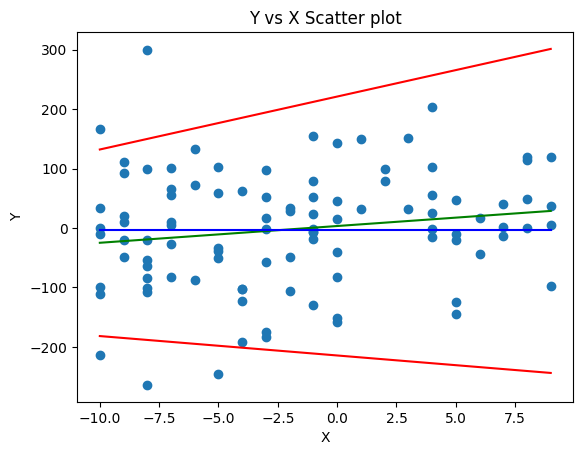

In [729]:
min_x = np.min(X)
max_x = np.max(X)
x_linspace = np.linspace(min_x,max_x, num=100)
x_fitted = np.vstack((np.ones((100,)), x_linspace)).T

y_fitted = x_fitted.dot(beta_hat)
y_fitted_upper = x_fitted.dot(beta_hat_upper)
y_fitted_lower = x_fitted.dot(beta_hat_lower)
y_true = x_fitted.dot(beta)

plt.scatter(X[:,1], Y)
plt.plot(x_linspace, y_fitted, color="green", label="beta_hat")
plt.plot(x_linspace, y_true, color="blue", label="beta_true")
plt.plot(x_linspace, y_fitted_upper, color="red", label="beta_hat upper bound")
plt.plot(x_linspace, y_fitted_lower, color="red", label="beta_hat lower bound")
plt.title("Y vs X Scatter plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()